## 1. 外れ値の探索

数値型データから外れ値（outlier）を判別する代表的な方法として、
<span style="color:red;">IQR</span> と <span style="color:red;">Z-score</span> がある。<br>
(外れ値 : 一般的な範囲から大きく外れた値)


<div style="background-color:#f1f3f4; padding:0;">

<div style="background-color:#e5e7e9; padding:6px 16px;">
<span style="color:#ff5a36;">IQR</span>
</div>

<div style="background-color:#f1f3f4; padding:6px 16px;">
<span style="color:#111111;">→</span>
<span style="color:#6b8e23;">「中央の 50% からどれくらい遠く離れているか？」</span>
</div>

<div style="background-color:#e5e7e9; padding:6px 16px;">
<span style="color:#ff5a36;">Z-score</span>
</div>

<div style="background-color:#f1f3f4; padding:6px 16px;">
<span style="color:#111111;">→</span>
<span style="color:#6b8e23;">「平均から標準偏差を基準に、どれくらい遠く離れているか？」</span>
</div>

</div>

<br>

<div style="color:red;">

注意）  
外れ値の検出基準 ≠ 外れ値の処理基準  

<strong>「検出」</strong>は統計的な方法で行うことができるが、<strong>「処理」</strong>はデータの意味と分析目的を考慮して決定（削除／変更／置換）する。

</div>

<br>

## 1) IQR 

IQRは、`データの中央50%がどの範囲に分布しているか`を表す値である。  
第1四分位数（Q1）と第3四分位数（Q3）の差として求める。

`IQR = Q3 - Q1`

IQR方式では、Q1とQ3を基準にして外れ値の下限・上限を設定する。

- `下限値` = Q1 - 1.5 × IQR
- `上限値` = Q3 + 1.5 × IQR

IQRは、正規分布を前提としないため、さまざまな分布のデータに利用できる。

ただし、データの分布によっては正常な値まで外れ値として判定される場合があるため、`データの意味や分布もあわせて確認することが重要`である。

In [1]:
import pandas as pd

data = {
    "score": [5, 65, 70, 72, 95, 78, 80, 0, 82, 85, 88, 75, 135, 150]
}

df = pd.DataFrame(data)

print(df)

    score
0       5
1      65
2      70
3      72
4      95
5      78
6      80
7       0
8      82
9      85
10     88
11     75
12    135
13    150


#### ※ 四分位数と各区間の意味

<table align="left">
  <thead>
    <tr>
      <th>区間</th>
      <th>意味</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>0% ～ 25%</td>
      <td>第1四分位数（Q1）</td>
    </tr>
    <tr>
      <td>25% ～ 50%</td>
      <td>第2四分位数（Q2 = 中央値）</td>
    </tr>
    <tr>
      <td>50% ～ 75%</td>
      <td>第3四分位数（Q3）</td>
    </tr>
    <tr>
      <td>75% ～ 100%</td>
      <td>第4区間</td>
    </tr>
  </tbody>
</table>

<br clear="left">

In [ ]:
# 第1四分位数 / 第3四分位数
Q1 = df["score"].quantile(0.25)
Q3 = df["score"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

# IQRの計算
IQR = Q3 - Q1
print("IQR:", IQR)

# 下限値/上限値の計算
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("下限値:", lower)
print("上限値:", upper)

Q1: 70.5
Q3: 87.25
IQR: 16.75
下限: 45.375
上限: 112.375


In [3]:
# 外れ値判定
print(df[(df["score"] < lower) | (df["score"] > upper)])

    score
0       5
7       0
12    135
13    150


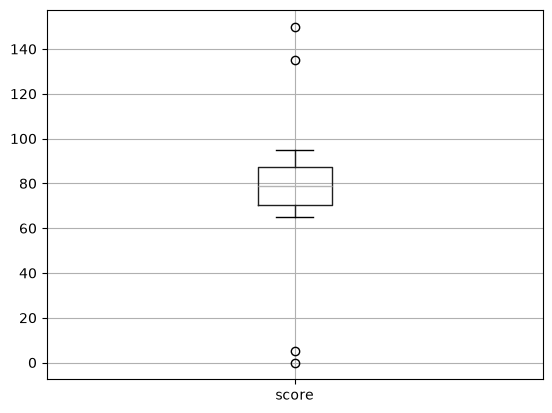

In [4]:
# boxplotで探索して確認することもできる
import matplotlib.pyplot as plt
df.boxplot()
plt.show()

## 2) Z-score

Z-scoreは、`平均からどれくらい離れているか`を標準偏差を基準に表した値である。  
外れ値を判定する際、`IQR方式は中央値を基準とした四分位数（Q1, Q3）`を利用するため、極端な値の影響を比較的受けにくい。

一方、`Z-scoreは平均と標準偏差を利用する`ため、外れ値が平均と標準偏差そのものに影響を与えることがある。特に極端値が含まれると、平均と標準偏差がともに変化し、外れ値判定の結果にも影響を与える可能性がある。  
したがって、Z-scoreを用いた外れ値判定では、`データの大きさだけでなく、データの分布や正規性の有無、極端値の有無などをあわせて考慮することが重要`である。

Z-scoreでは、値が平均と同じなら 0、平均から標準偏差1個分だけ離れていれば -1 または +1

<div style="background-color:#232627; padding:0;">

<div style="background-color:#2b2f30; padding:7px 16px;">
<span style="color:#f2f2f2;">Z-score = (個別値 - 平均) / 標準偏差</span>
</div>

</div>

一般的には、<span style="color:red;">|Z-score| > 3</span> を外れ値と判断する基準としてよく使用する。

<br>

In [14]:
# SciPyでZ-scoreを計算
from scipy.stats import zscore

# データ数が少ない場合や値の分布によっては、大きな値でもZ-scoreが3未満になることがある。
# この例では、Z-score > 3を明確に確認できるように、データの値をより極端に設定する。

data = {
    "試験点数": [
        65, 70, 72, 75, 78,
        80, 82, 85, 88, 95, 200
    ]
}

df = pd.DataFrame(data)

df["z_score"] = zscore(df["試験点数"])

display(df)

print()

print("外れ値:")

outlier = df[abs(df["z_score"]) > 3]
outlier

,試験点数,z_score
0,65,-0.699866
1,70,-0.559893
2,72,-0.503903
3,75,-0.419919
4,78,-0.335936
5,80,-0.279946
6,82,-0.223957
7,85,-0.139973
8,88,-0.055989
9,95,0.139973



外れ値:


,試験点数,z_score
10,200,3.079409


## 2. 外れ値処理

外れ値を処理する3つの方法

① `削除（Deletion）`：外れ値をデータセットから除外する。ただし、データの損失が発生するため慎重に行う必要がある。

② `置換（Replacement）`：外れ値を、先ほど計算した「下限値」または「上限値」に強制的に調整し、データの範囲を制限する。

(欠損値の処理方法と類似している)

#### ※ 欠損値と外れ値の処理方法の比較

<div style="background-color:#232627; padding:0;">

<div style="background-color:#2b2f30; padding:7px 16px; color:#f2f2f2;">
<code>欠損値</code> → 平均値、中央値、最頻値、予測値など
</div>

<div style="background-color:#232627; padding:7px 16px; color:#f2f2f2;">
<code>外れ値</code> → 下限値、上限値などで制限する方法がある
</div>

</div>

③ `変換（Transformation）`：自然対数を用いる`対数変換（Log Transform）`などによって、データの変動性を小さくする。